# 🏨 Hotel Booking Cancellation Prediction Using Ensemble Learning

## Objective

This project aims to predict whether a hotel booking will be cancelled using Machine Learning.

Three models will be compared:

- Decision Tree
- Random Forest
- XGBoost

The project includes:

- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Feature Engineering
- Hyperparameter Tuning
- Model Comparison

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("D:\Hotel-Booking-Cancellation-Using-Ensemble-Learning\Hotel-Booking-Cancellation-Using-Ensemble-Learning\data\hotel_bookings.csv")

In [4]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [6]:
df.shape

(119390, 32)

In [7]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [9]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [10]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

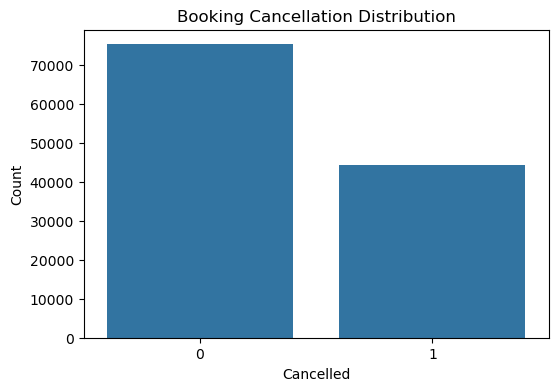

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x="is_canceled", data=df)
plt.title("Booking Cancellation Distribution")
plt.xlabel("Cancelled")
plt.ylabel("Count")
plt.show()

## Observation

The distribution of cancelled and non-cancelled bookings was visualized to understand whether the dataset is balanced or imbalanced.

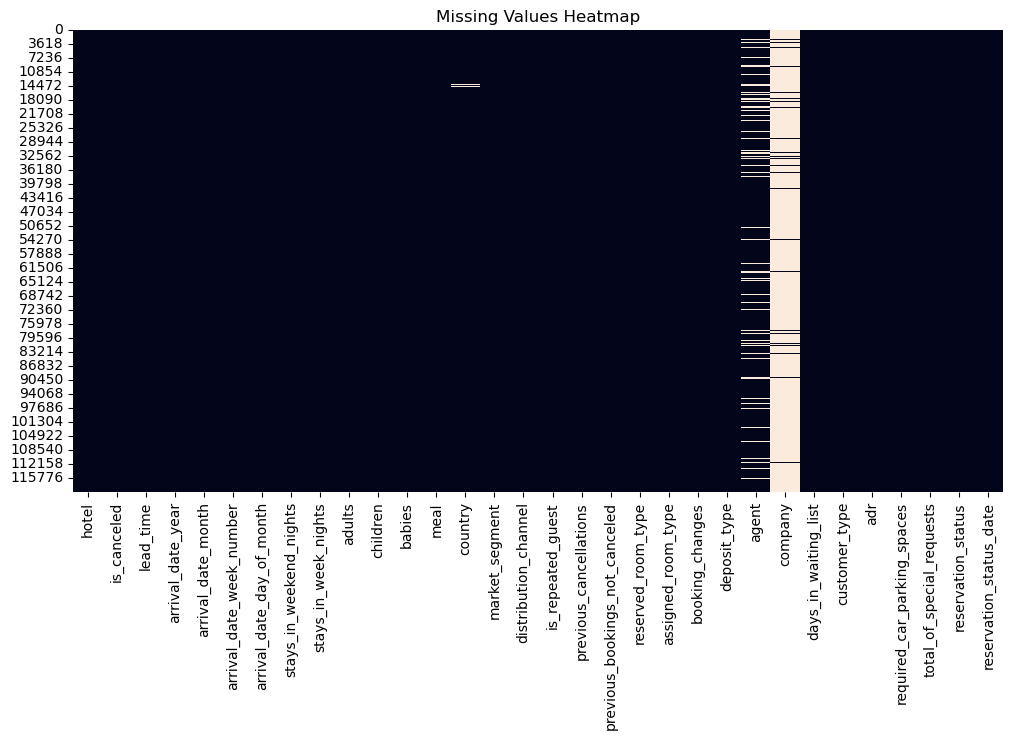

In [12]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

## Observation

The heatmap highlights columns containing missing values, which will guide the preprocessing stage.

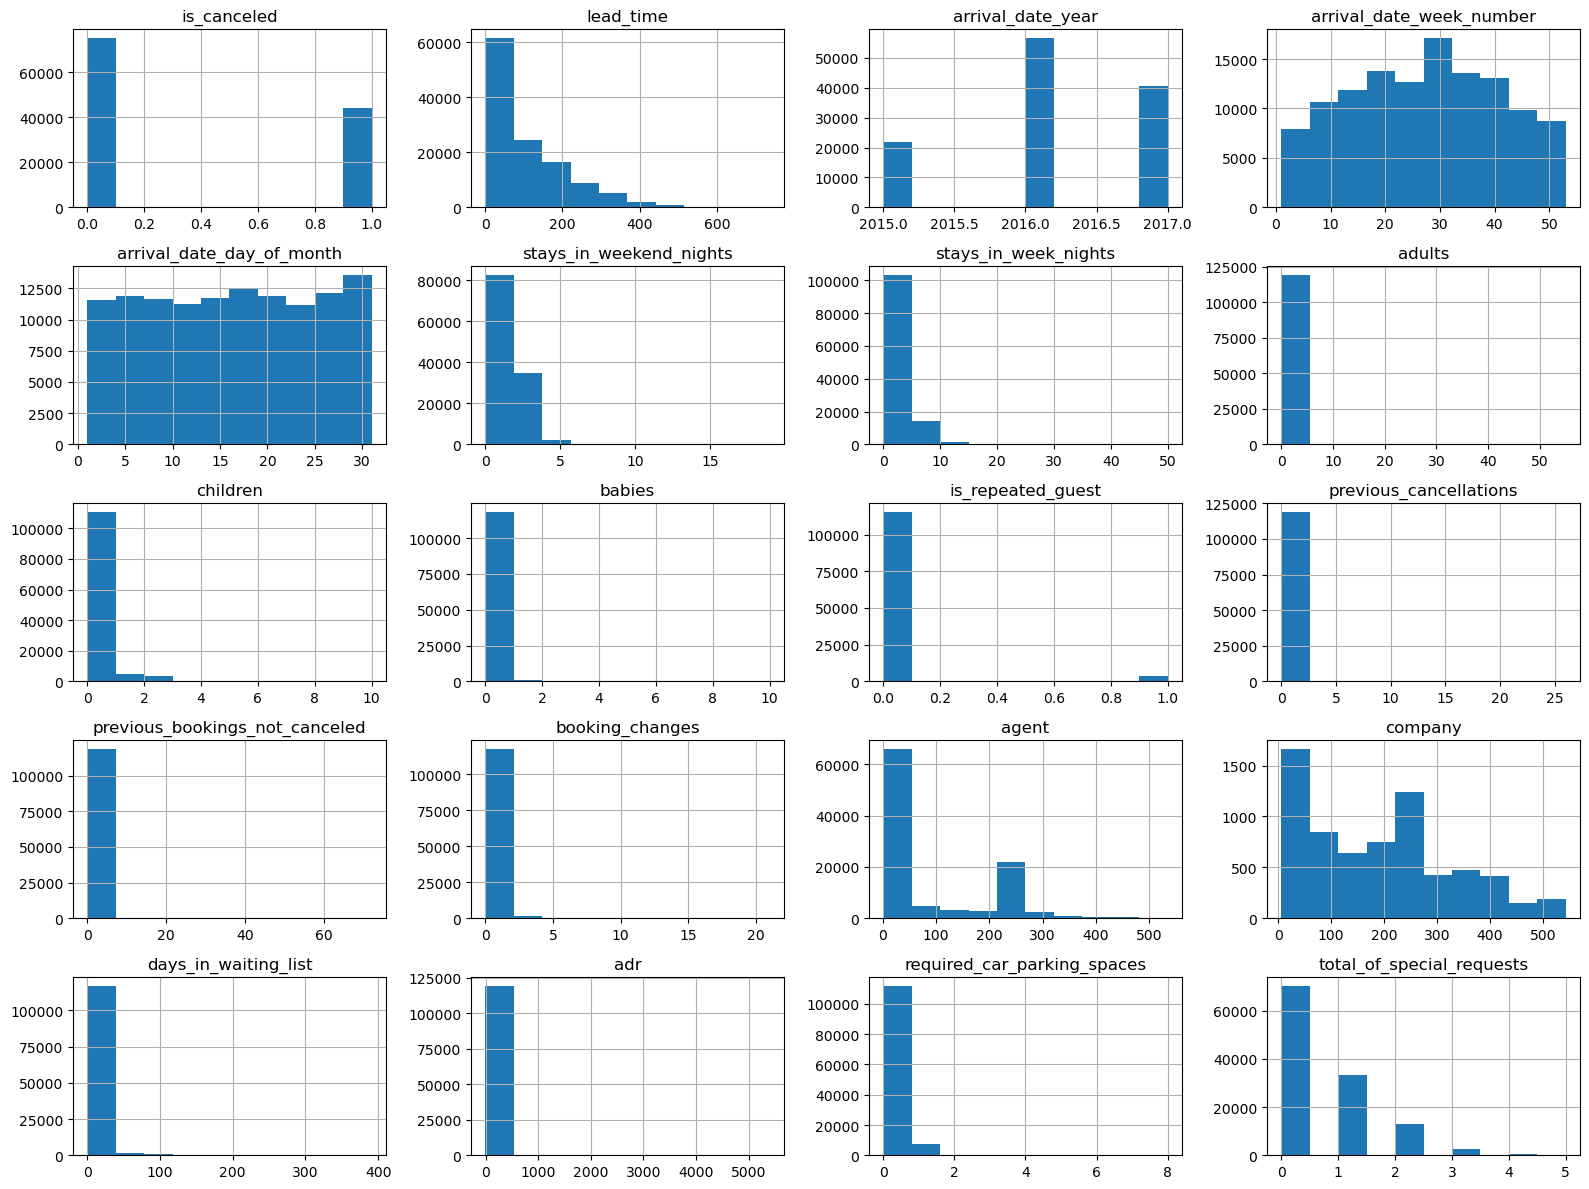

In [20]:
numerical_columns = df.select_dtypes(include=["int64","float64"]).columns

df[numerical_columns].hist(figsize=(16,12))
plt.tight_layout()
plt.show()

## Observation

The numerical feature distributions were examined to identify skewness, outliers, and unusual value ranges.

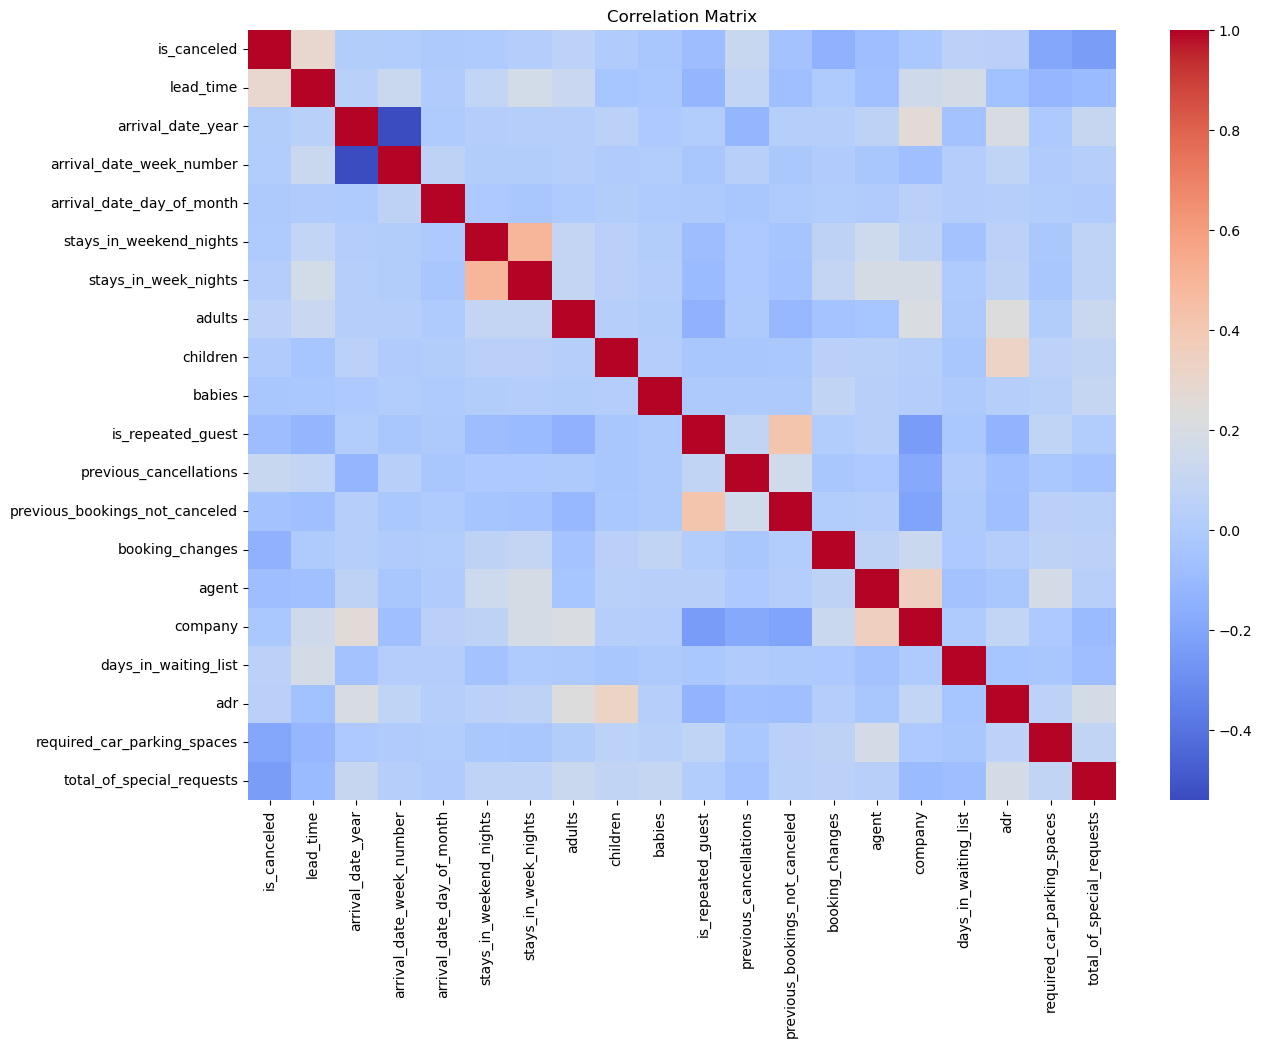

In [14]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df[numerical_columns].corr(),
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

## Observation

The correlation matrix was used to identify relationships among numerical features and detect highly correlated variables.

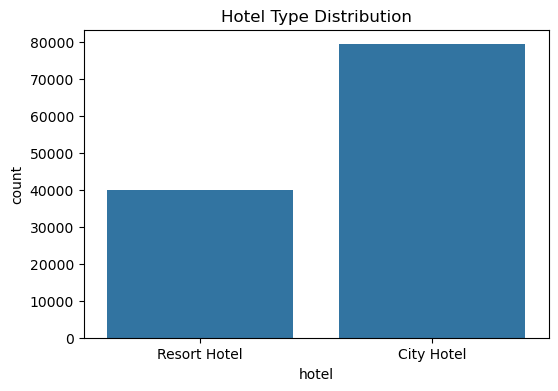

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x="hotel", data=df)
plt.title("Hotel Type Distribution")
plt.show()

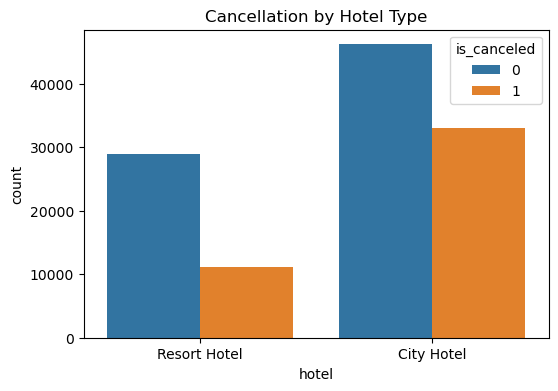

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(
    x="hotel",
    hue="is_canceled",
    data=df
)

plt.title("Cancellation by Hotel Type")
plt.show()

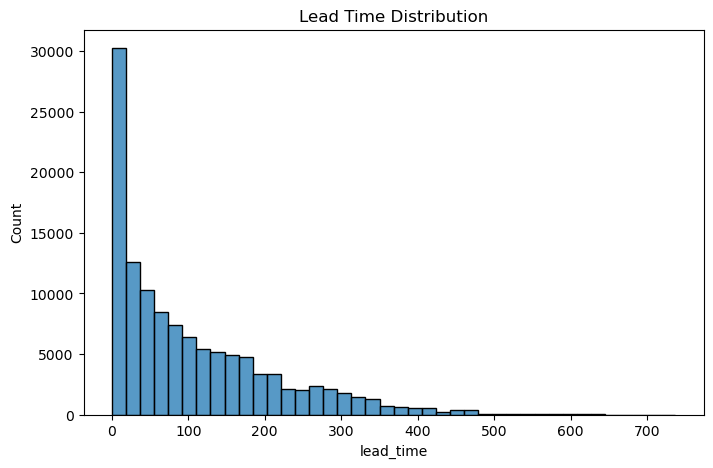

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["lead_time"],
    bins=40
)

plt.title("Lead Time Distribution")
plt.show()

## Overall EDA Summary

- Explored the target variable distribution.
- Identified missing values.
- Examined numerical feature distributions.
- Analyzed correlations among numerical features.
- Compared hotel types.
- Observed booking cancellation trends.
- Studied booking lead time.

These observations will guide data preprocessing and feature engineering in the next phase.

In [21]:
df.duplicated().sum()

np.int64(31994)

In [24]:
df.isnull().sum().sort_values(ascending=False)

company                           112593
agent                              16340
country                              488
children                               4
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
hotel                                  0
previous_cancellations                 0
days_in_waiting_list                   0
customer_type                          0
adr                                    0
required_car_parking_spaces            0
total_of_special_requests              0
reservation_status                     0
previous_bookings_not_canceled         0
is_repeated_guest                      0
is_canceled                            0
distribution_channel                   0
market_segment                         0
meal                                   0
babies                                 0
adults                                 0
stays_in_week_ni

In [29]:
missing = (df.isnull().sum() / len(df)) * 100
missing.sort_values(ascending=False)

agent                             13.951439
country                            0.517186
children                           0.004577
hotel                              0.000000
previous_cancellations             0.000000
reservation_status                 0.000000
total_of_special_requests          0.000000
required_car_parking_spaces        0.000000
adr                                0.000000
customer_type                      0.000000
days_in_waiting_list               0.000000
deposit_type                       0.000000
booking_changes                    0.000000
assigned_room_type                 0.000000
reserved_room_type                 0.000000
previous_bookings_not_canceled     0.000000
distribution_channel               0.000000
is_repeated_guest                  0.000000
is_canceled                        0.000000
market_segment                     0.000000
meal                               0.000000
babies                             0.000000
adults                          

In [26]:
print("Shape before removing duplicates:", df.shape)
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape before removing duplicates: (119390, 32)
Shape after removing duplicates: (87396, 32)


In [27]:
df = df.drop(columns=["company"])

In [28]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

## Data Cleaning - Part 1

- Duplicate rows were removed to avoid bias during model training.
- The company column was dropped because it contained approximately 94% missing values, making it unsuitable for reliable analysis.

In [30]:
df["children"] = df["children"].fillna(df["children"].median())

In [31]:
df["country"] = df["country"].fillna(df["country"].mode()[0])

In [33]:
df["agent"] = df["agent"].fillna(df["agent"].mode()[0])

In [34]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

## Data Cleaning - Part 2

Missing values were handled based on the data type of each feature.

- children was filled using the median because it is a numerical feature.
- country was filled using the mode because it is a categorical feature.
- agent was filled using the mode because it represents an identifier rather than a continuous numerical value.

After imputation, the dataset contained no missing values in the remaining columns.

# Feature Engineering

In [36]:
hotel_df = df.copy()

In [37]:
hotel_df["total_guests"] = (
    hotel_df["adults"]
    + hotel_df["children"]
    + hotel_df["babies"]
)

In [38]:
hotel_df["total_nights"] = (
    hotel_df["stays_in_weekend_nights"]
    + hotel_df["stays_in_week_nights"]
)

In [39]:
hotel_df["is_family"] = (
    (hotel_df["children"] > 0)
    | (hotel_df["babies"] > 0)
).astype(int)

In [40]:
hotel_df["previous_customer"] = hotel_df["is_repeated_guest"]

In [41]:
hotel_df["high_special_requests"] = (
    hotel_df["total_of_special_requests"] >= 2
).astype(int)

In [42]:
hotel_df[
    [
        "total_guests",
        "total_nights",
        "is_family",
        "previous_customer",
        "high_special_requests"
    ]
].head()

,total_guests,total_nights,is_family,previous_customer,high_special_requests
0,2.0,0,0,0,0
1,2.0,0,0,0,0
2,1.0,1,0,0,0
3,1.0,1,0,0,0
4,2.0,2,0,0,0


In [43]:
hotel_df.drop(
    columns=[
        "reservation_status",
        "reservation_status_date"
    ],
    inplace=True
)

In [44]:
hotel_df.select_dtypes(include="object").columns

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type'],
      dtype='object')

In [45]:
hotel_df = pd.get_dummies(
    hotel_df,
    drop_first=True
)

print(hotel_df.shape)
hotel_df.head()

(87396, 252)


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,assigned_room_type_H,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L,assigned_room_type_P,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,0,342,2015,27,1,0,0,2,0.0,0,...,False,False,False,False,False,False,False,False,True,False
1,0,737,2015,27,1,0,0,2,0.0,0,...,False,False,False,False,False,False,False,False,True,False
2,0,7,2015,27,1,0,1,1,0.0,0,...,False,False,False,False,False,False,False,False,True,False
3,0,13,2015,27,1,0,1,1,0.0,0,...,False,False,False,False,False,False,False,False,True,False
4,0,14,2015,27,1,0,2,2,0.0,0,...,False,False,False,False,False,False,False,False,True,False


In [47]:
# Estimated Total Booking Cost
hotel_df["estimated_total_cost"] = (
    hotel_df["adr"] * hotel_df["total_nights"]
)

# Cost Per Guest
hotel_df["cost_per_guest"] = (
    hotel_df["adr"] / hotel_df["total_guests"].replace(0, 1)
)

# Booking Changes Per Night
hotel_df["changes_per_night"] = (
    hotel_df["booking_changes"] /
    (hotel_df["total_nights"] + 1)
)

# Cancellation Risk Score
hotel_df["risk_score"] = (
    hotel_df["lead_time"] *
    hotel_df["previous_cancellations"]
)

In [48]:
hotel_df["is_couple"] = (
    (hotel_df["adults"] == 2) &
    (hotel_df["children"] == 0) &
    (hotel_df["babies"] == 0)
).astype(int)

In [49]:
hotel_df["estimated_booking_value"] = (
    hotel_df["adr"] *
    hotel_df["total_nights"]
)

In [50]:
hotel_df["cost_per_guest"] = (
    hotel_df["adr"] /
    hotel_df["total_guests"].replace(0,1)
)

In [51]:
hotel_df["long_stay"] = (
    hotel_df["total_nights"] >= 7
).astype(int)

In [53]:
hotel_df["is_couple"] = (
    (hotel_df["adults"] == 2) &
    (hotel_df["children"] == 0) &
    (hotel_df["babies"] == 0)
).astype(int)

In [54]:
hotel_df["risk_score"] = (
    hotel_df["lead_time"] *
    hotel_df["previous_cancellations"]
)

In [55]:
new_features = [
    "estimated_booking_value",
    "cost_per_guest",
    "long_stay",
    "is_couple",
    "risk_score"
]

hotel_df[new_features].head()

,estimated_booking_value,cost_per_guest,long_stay,is_couple,risk_score
0,0.0,0.0,0,1,0
1,0.0,0.0,0,1,0
2,75.0,75.0,0,0,0
3,75.0,75.0,0,0,0
4,196.0,49.0,0,1,0


In [56]:
# Features
X = hotel_df.drop("is_canceled", axis=1)

# Target
y = hotel_df["is_canceled"]

print("Features :", X.shape)
print("Target :", y.shape)

Features : (87396, 258)
Target : (87396,)


In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [60]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [62]:
y_pred = lr_model.predict(X_test_scaled)

In [63]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.7969
Precision: 0.6833
Recall   : 0.4864
F1 Score : 0.5683


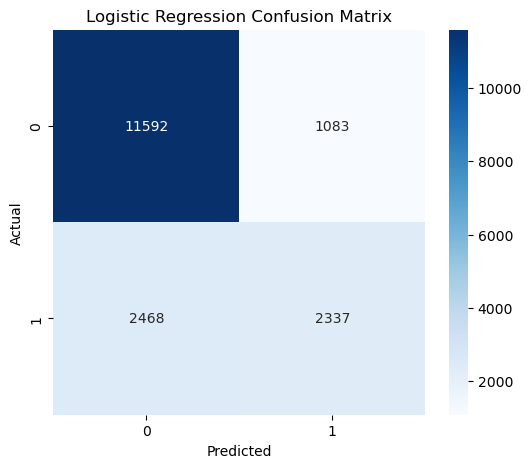

In [64]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()